In [15]:
from neo4j import GraphDatabase

URI = "neo4j://localhost:7687"
AUTH = ("neo4j", "password")

driver =  GraphDatabase.driver(URI, auth=AUTH)

In [30]:
#adding some contrains for unique values
cyphers = [
"CREATE CONSTRAINT FOR (m:Movie) REQUIRE m.movieId IS UNIQUE",
"CREATE CONSTRAINT FOR (u:User) REQUIRE u.userId IS UNIQUE",
"CREATE CONSTRAINT FOR (g:Genre) REQUIRE g.name IS UNIQUE",
"CREATE CONSTRAINT FOR (t:Tag) REQUIRE t.name IS UNIQUE"
]

for c in cyphers:
    driver.execute_query(c,database_='movies')

In [31]:
# adding index for some field for faster searching and lookup
cyphers = [
"CREATE INDEX FOR (m:Movie) ON (m.imdbId)",
"CREATE INDEX FOR (u:User) ON (u.name)"
]
for c in cyphers:
    driver.execute_query(c,database_='movies')

In [32]:
#load movies
cypher= """
LOAD CSV WITH HEADERS FROM "file:///movies.csv" AS row
MERGE (m:Movie {movieId:row.movieId})
ON CREATE SET m.title = row.title
WITH *
UNWIND split(row.genres,"|") AS genre
MERGE (g:Genre {name:genre})
MERGE (m)-[:IN_GENRE]->(g)
"""

result = driver.execute_query(cypher,database_='movies')

In [37]:
#load ratings
cypher = """
LOAD CSV WITH HEADERS FROM "file:///ratings.csv" as row
MERGE (u:User {userId:row.userId})
WITH *
MATCH (m:Movie {movieId:row.movieId})
MERGE (u)-[r:RATED]->(m)
SET r.rating = toFloat(row.rating),
    r.timestamp = toInteger(row.timestamp)
"""

result = driver.execute_query(cypher,database_='movies')

In [38]:
#load links
cypher = """
LOAD CSV WITH HEADERS FROM "file:///links.csv" AS row
MATCH (m:Movie {movieId: row.movieId})
SET m.imdbId = row.imdbId,
    m.tmdbId = row.tmdbId
"""
result = driver.execute_query(cypher,database_='movies')

In [40]:
#load tags added by users
cypher = """
LOAD CSV WITH HEADERS FROM "file:///tags.csv" as row
MERGE (u:User {userId:row.userId})
WITH *
MATCH (m:Movie {movieId:row.movieId})
MERGE (t:Tag {name:row.tag})
MERGE (u)-[r:TAGGED]->(m)
SET r.tag = row.tag,
    r.timestamp = toInteger(row.timestamp)
"""
result = driver.execute_query(cypher,database_='movies')

In [41]:
# find movies similar to matrix 
cypher = """
MATCH (m:Movie) WHERE m.title CONTAINS "Matrix"
MATCH (m)-[:IN_GENRE]->(g:Genre)<-[:IN_GENRE]-(rec:Movie)
RETURN rec, count(*) AS num ORDER BY num DESC LIMIT 10;
"""
result = driver.execute_query(cypher,database_='movies')

In [45]:
for record in result.records:
    node = record["rec"]  # or record['m'] if you returned 'm'
    print(f"MovieID: {node['movieId']}, Title: {node['title']}, IMDb: {node['imdbId']}, TMDb: {node['tmdbId']}")

MovieID: 52722, Title: Spider-Man 3 (2007), IMDb: 0413300, TMDb: 559
MovieID: 77561, Title: Iron Man 2 (2010), IMDb: 1228705, TMDb: 10138
MovieID: 101076, Title: G.I. Joe: Retaliation (2013), IMDb: 1583421, TMDb: 72559
MovieID: 1591, Title: Spawn (1997), IMDb: 0120177, TMDb: 10336
MovieID: 1374, Title: Star Trek II: The Wrath of Khan (1982), IMDb: 0084726, TMDb: 154
MovieID: 1544, Title: Lost World: Jurassic Park, The (1997), IMDb: 0119567, TMDb: 330
MovieID: 1129, Title: Escape from New York (1981), IMDb: 0082340, TMDb: 1103
MovieID: 780, Title: Independence Day (a.k.a. ID4) (1996), IMDb: 0116629, TMDb: 602
MovieID: 1127, Title: Abyss, The (1989), IMDb: 0096754, TMDb: 2756
MovieID: 480, Title: Jurassic Park (1993), IMDb: 0107290, TMDb: 329


In [64]:
#Content recommendation by overlapping genres
cypher = """
MATCH (u:User {userId: "1"})
MATCH (u)-[r:RATED]->(m:Movie)
MATCH (m)-[:IN_GENRE]->(g:Genre)<-[:IN_GENRE]-(rec:Movie)
RETURN rec.title, COUNT(*) AS score ORDER BY score DESC LIMIT 10;
"""
result = driver.execute_query(cypher,database_='movies')

for record in result.records:
    # node = record["rec"]  # or record['m'] if you returned 'm'
    print(f"Title: {record.values()[0]}")

Title: Confessions of a Dangerous Mind (2002)
Title: Rubber (2010)
Title: Dragonheart 2: A New Beginning (2000)
Title: Aelita: The Queen of Mars (Aelita) (1924)
Title: Stunt Man, The (1980)
Title: War of the Worlds (2005)
Title: Maximum Ride (2016)
Title: Interstate 60 (2002)
Title: Osmosis Jones (2001)
Title: Aqua Teen Hunger Force Colon Movie Film for Theaters (2007)


In [79]:
# Show all ratings by  user id 1
cypher = """
MATCH (u:User {userId: "1"})
MATCH (u)-[r:RATED]->(m:Movie)
RETURN *;
"""
result = driver.execute_query(cypher,database_='movies')

for record in result.records:
    movie = record["m"]
    rel = record["r"]
    user = record["u"]
    
    print(f"UserID: {user['userId']} -> Movie: {movie['title']} ({movie['movieId']})")
    print(f"   Relationship: {rel.type}, Rating: {rel['rating']}, Timestamp: {rel['timestamp']}")
    print("-" * 60)


UserID: 1 -> Movie: Toy Story (1995) (1)
   Relationship: RATED, Rating: 4.0, Timestamp: 964982703
------------------------------------------------------------
UserID: 1 -> Movie: Grumpier Old Men (1995) (3)
   Relationship: RATED, Rating: 4.0, Timestamp: 964981247
------------------------------------------------------------
UserID: 1 -> Movie: Heat (1995) (6)
   Relationship: RATED, Rating: 4.0, Timestamp: 964982224
------------------------------------------------------------
UserID: 1 -> Movie: Seven (a.k.a. Se7en) (1995) (47)
   Relationship: RATED, Rating: 5.0, Timestamp: 964983815
------------------------------------------------------------
UserID: 1 -> Movie: Usual Suspects, The (1995) (50)
   Relationship: RATED, Rating: 5.0, Timestamp: 964982931
------------------------------------------------------------
UserID: 1 -> Movie: From Dusk Till Dawn (1996) (70)
   Relationship: RATED, Rating: 3.0, Timestamp: 964982400
------------------------------------------------------------
User

In [84]:
# What are the movies that user id 1 liked more than average?

cypher = """
MATCH (u:User {userId:"1"})
MATCH (u)-[r:RATED]->(m:Movie)
WITH u, avg(r.rating) AS average
MATCH (u)-[r:RATED]->(m:Movie)
WHERE r.rating > average
RETURN *;
"""
result = driver.execute_query(cypher,database_='movies')
for record in result.records:
    movie = record["m"]
    rel = record["r"]
    user = record["u"]
    average = record["average"]

    print(f"UserID: {user['userId']} -> Movie: {movie['title']} ({movie['movieId']})")
    print(f"   Rating Given: {rel['rating']}, Timestamp: {rel['timestamp']}, Average Rating: {average:.2f}")
    print("-" * 80)

UserID: 1 -> Movie: Seven (a.k.a. Se7en) (1995) (47)
   Rating Given: 5.0, Timestamp: 964983815, Average Rating: 4.37
--------------------------------------------------------------------------------
UserID: 1 -> Movie: Usual Suspects, The (1995) (50)
   Rating Given: 5.0, Timestamp: 964982931, Average Rating: 4.37
--------------------------------------------------------------------------------
UserID: 1 -> Movie: Bottle Rocket (1996) (101)
   Rating Given: 5.0, Timestamp: 964980868, Average Rating: 4.37
--------------------------------------------------------------------------------
UserID: 1 -> Movie: Rob Roy (1995) (151)
   Rating Given: 5.0, Timestamp: 964984041, Average Rating: 4.37
--------------------------------------------------------------------------------
UserID: 1 -> Movie: Canadian Bacon (1995) (157)
   Rating Given: 5.0, Timestamp: 964984100, Average Rating: 4.37
--------------------------------------------------------------------------------
UserID: 1 -> Movie: Desperado

In [92]:
import networkx as nx
import matplotlib.pyplot as plt


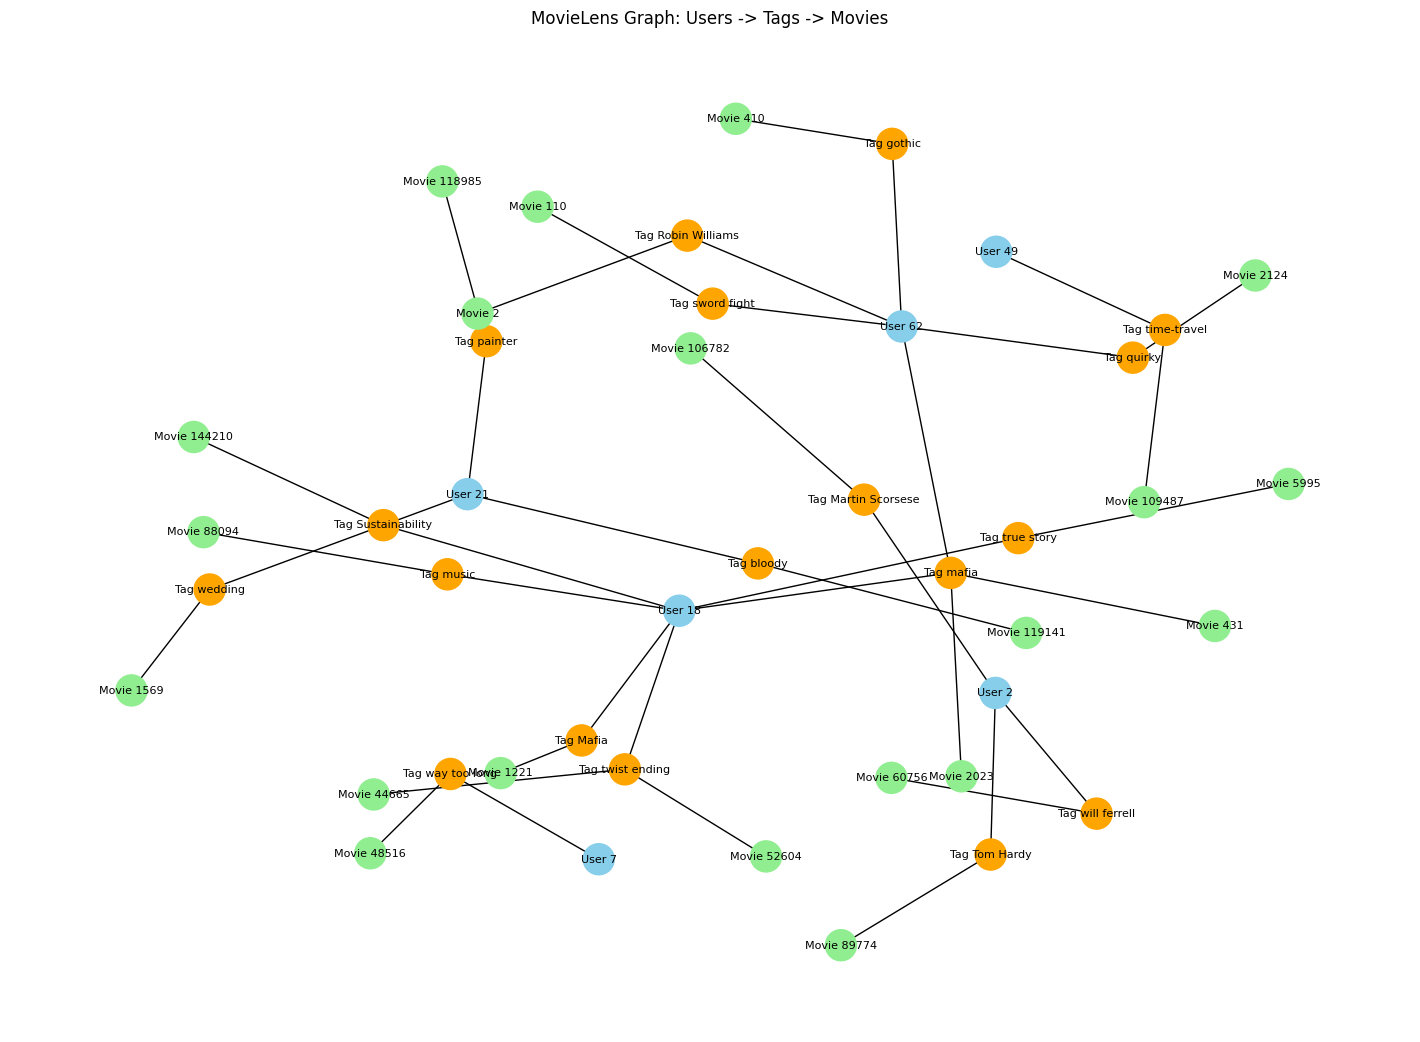

In [98]:
#plotting the graph of tags added by user to a movie
cypher = """
MATCH (u:User)-[t:TAGGED]->(m:Movie)
RETURN u.userId AS user, m.movieId AS movie, t.tag AS tag
LIMIT 20
"""

G3 = nx.Graph()
with driver.session(database="movies") as session:
    result = session.run(cypher)
    for record in result:
        user = f"User {record['user']}"
        movie = f"Movie {record['movie']}"
        tag = f"Tag {record['tag']}"
        G3.add_node(user, type='user')
        G3.add_node(movie, type='movie')
        G3.add_node(tag, type='tag')
        G3.add_edge(user, tag)
        G3.add_edge(tag, movie)

pos = nx.spring_layout(G3, k=0.5, iterations=50)

colors = []
for n in G3.nodes:
    t = G3.nodes[n]['type']
    if t == 'user': colors.append('skyblue')
    elif t == 'movie': colors.append('lightgreen')
    else: colors.append('orange')

plt.figure(figsize=(14,10))
nx.draw(G3, pos, with_labels=True, node_color=colors, node_size=500, font_size=8)
plt.title("MovieLens Graph: Users -> Tags -> Movies")
plt.show()

In [99]:
session = driver.session(database="movies")
session.close()
driver.close()